# 02 — Preprocesado y Feature Engineering
**Proyecto:** ML_Churn_Bancario


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
sns.set_style('whitegrid')
SEED = 42

df = pd.read_csv('src/data_sample/churn.csv')
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
X = df.drop('Exited', axis=1)
y = df['Exited']
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'   Dataset cargado: {df.shape}')
print(f'   Numéricas: {num_cols}')
print(f'   Categóricas: {cat_cols}')

   Dataset cargado: (10000, 11)
   Numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
   Categóricas: ['Geography', 'Gender']


## 1. Train / Test Split

Primero separamos. Todo el preprocesado se aprende en train y se aplica en test.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Proporción churn train: {y_train.mean()*100:.1f}%')
print(f'Proporción churn test:  {y_test.mean()*100:.1f}%')
print('→ Proporciones iguales gracias a stratify ')

Train: 8,000 | Test: 2,000
Proporción churn train: 20.4%
Proporción churn test:  20.3%
→ Proporciones iguales gracias a stratify 


### Regla de oro del pipeline
> A partir de aquí, cualquier estadístico — mediana, percentiles, media del scaler —
> se calcula **SOLO en train** y se aplica igual en test.
> Si no, el modelo ve información del futuro → **data leakage**

## 2. Duplicados

In [3]:
train_full = X_train.copy()
train_full['Exited'] = y_train.values
n_dup = train_full.duplicated().sum()
print(f'Duplicados encontrados: {n_dup}')
if n_dup > 0:
    train_full = train_full.drop_duplicates()
    X_train = train_full.drop('Exited', axis=1)
    y_train = train_full['Exited']
    print(f' Eliminados. Nuevo tamaño: {X_train.shape[0]:,}')
else:
    print(' Sin duplicados — no se requiere acción')

Duplicados encontrados: 0
 Sin duplicados — no se requiere acción


### Por qué importa eliminar duplicados
Un duplicado en train significa que el modelo ve el mismo ejemplo varias veces.
Esto sesga el aprendizaje y distorsiona las estadísticas de imputación y escalado.

## 3. Imputación de Nulos

In [4]:
print('Nulos en train:')
nulos = X_train.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '   Ninguno ')

Nulos en train:
   Ninguno 


In [5]:
# Mediana para numéricas — robusta a outliers
# Moda para categóricas — valor más frecuente
# Fit SOLO en train, transform en ambos
cols_nulos_num = [c for c in num_cols if X_train[c].isnull().sum() > 0]
cols_nulos_cat = [c for c in cat_cols if X_train[c].isnull().sum() > 0]

if cols_nulos_num:
    imputer_num = SimpleImputer(strategy='median')
    X_train[cols_nulos_num] = imputer_num.fit_transform(X_train[cols_nulos_num])
    X_test[cols_nulos_num]  = imputer_num.transform(X_test[cols_nulos_num])
    print(f' Imputadas con mediana: {cols_nulos_num}')
else:
    imputer_num = SimpleImputer(strategy='median')
    imputer_num.fit(X_train[num_cols])
    print(' Sin nulos — imputador ajustado de forma preventiva para producción')

if cols_nulos_cat:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X_train[cols_nulos_cat] = imputer_cat.fit_transform(X_train[cols_nulos_cat])
    X_test[cols_nulos_cat]  = imputer_cat.transform(X_test[cols_nulos_cat])
    print(f' Imputadas con moda: {cols_nulos_cat}')

 Sin nulos — imputador ajustado de forma preventiva para producción


### ¿Por qué mediana y no media?
```
Ejemplo con Age:
Valores: [25, 30, 35, 40, 92]   ← el 92 es un outlier

Media   = (25+30+35+40+92) / 5 = 44.4  ← distorsionada por el extremo
Mediana = 35                            ← valor central real 
```

## 4. Outliers — Detección y Tratamiento

In [6]:
# Detección con método IQR
print(' Análisis de outliers:')
for col in num_cols:
    Q1, Q3 = X_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((X_train[col] < Q1-1.5*IQR) | (X_train[col] > Q3+1.5*IQR)).sum()
    pct = n_out/len(X_train)*100
    flag = ' Tratar' if pct > 1 else ' OK'
    print(f'  {col:20s}: {n_out:4d} outliers ({pct:.1f}%)  {flag}')

 Análisis de outliers:
  CreditScore         :   14 outliers (0.2%)   OK
  Age                 :  298 outliers (3.7%)   Tratar
  Tenure              :    0 outliers (0.0%)   OK
  Balance             :    0 outliers (0.0%)   OK
  NumOfProducts       :   50 outliers (0.6%)   OK
  HasCrCard           :    0 outliers (0.0%)   OK
  IsActiveMember      :    0 outliers (0.0%)   OK
  EstimatedSalary     :    0 outliers (0.0%)   OK


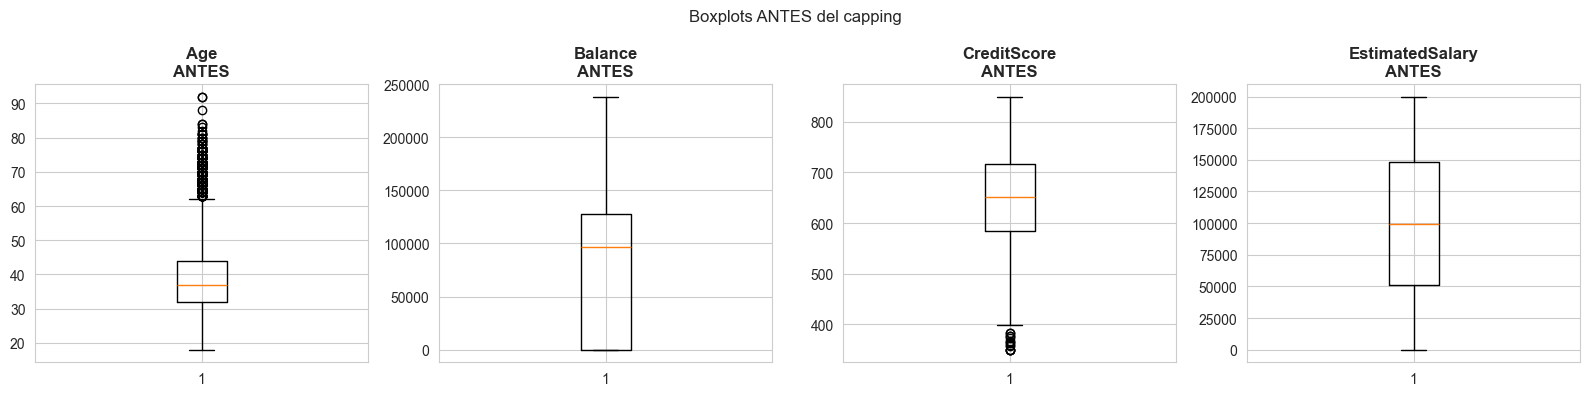

In [7]:
# Visualizamos ANTES del capping
cols_capping = ['Age','Balance','CreditScore','EstimatedSalary']
fig, axes = plt.subplots(1, len(cols_capping), figsize=(16,4))
for i, col in enumerate(cols_capping):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}\nANTES', fontweight='bold')
plt.suptitle('Boxplots ANTES del capping', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# Capping P1-P99 — límites calculados SOLO en train
# Conserva todos los registros recortando los valores extremos
capping_bounds = {}
print('  Aplicando capping P1-P99:')
for col in cols_capping:
    p1  = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    capping_bounds[col] = (p1, p99)
    X_train[col] = X_train[col].clip(p1, p99)
    X_test[col]  = X_test[col].clip(p1, p99)
    print(f'  {col:20s}: [{p1:.1f}, {p99:.1f}]')
print('\n Bounds aprendidos en train y aplicados en test → sin data leakage')

  Aplicando capping P1-P99:
  Age                 : [21.0, 72.0]
  Balance             : [0.0, 185932.5]
  CreditScore         : [431.0, 850.0]
  EstimatedSalary     : [2001.6, 198033.2]

 Bounds aprendidos en train y aplicados en test → sin data leakage


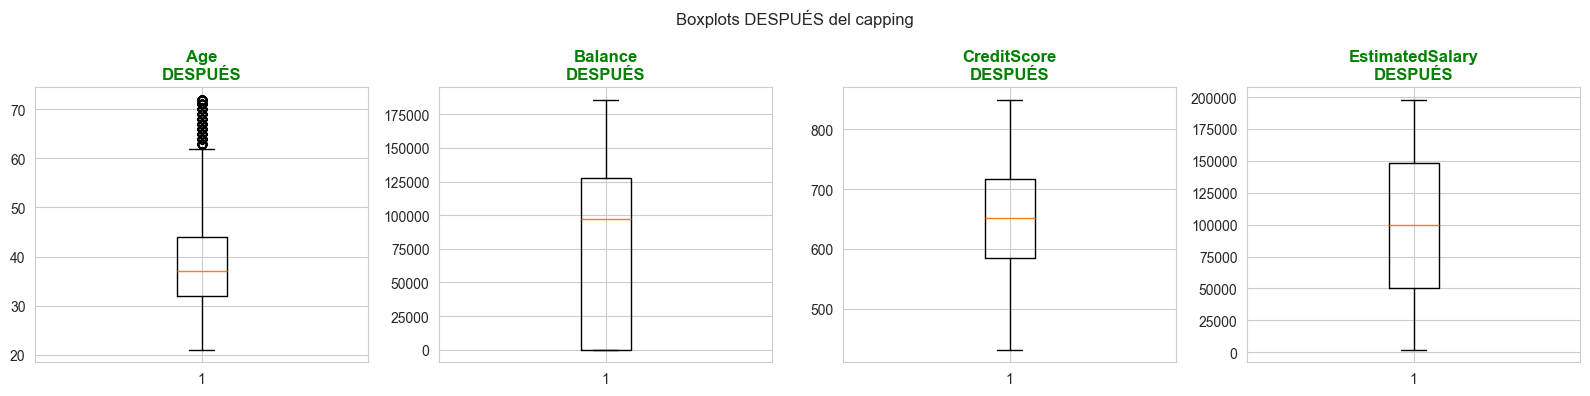

In [9]:
# Visualizamos DESPUÉS del capping
fig, axes = plt.subplots(1, len(cols_capping), figsize=(16,4))
for i, col in enumerate(cols_capping):
    axes[i].boxplot(X_train[col].dropna())
    axes[i].set_title(f'{col}\nDESPUÉS', fontweight='bold', color='green')
plt.suptitle('Boxplots DESPUÉS del capping', fontsize=12)
plt.tight_layout()
plt.show()

###  ¿Por qué capping y no eliminar filas?
| Opción | Decisión | Motivo |
|---|---|---|
| Eliminar filas con outliers |  Descartado | En producción no podemos "eliminar" un cliente real |
| **Capping P1-P99** |  Elegido | Conserva todos los registros — los extremos se recortan al límite razonable |

## 5. Feature Engineering

> Creamos todas las features **antes de escalar** — con los valores originales en su escala real.

In [10]:
# ---- Feature 1: balance_per_product ----
# Ratio de balance por número de productos contratados
# Un cliente con mucho dinero concentrado en pocos productos
# es más fácil de captar para la competencia con una buena oferta
X_train['balance_per_product'] = X_train['Balance'] / (X_train['NumOfProducts'] + 1)
X_test['balance_per_product']  = X_test['Balance']  / (X_test['NumOfProducts'] + 1)

temp = X_train.copy()
temp['Exited'] = y_train.values
corr = temp['balance_per_product'].corr(temp['Exited'])
print(f' balance_per_product → correlación con target: {corr:.4f}')

 balance_per_product → correlación con target: 0.1141


In [11]:
# ---- Feature 2: HasBalance ----
# Cliente con saldo positivo (1) vs saldo cero (0)
# El 36% de clientes tiene saldo 0 — puede ser señal de desenganche del banco
X_train['HasBalance'] = (X_train['Balance'] > 0).astype(int)
X_test['HasBalance']  = (X_test['Balance'] > 0).astype(int)

corr = temp['Balance'].corr(temp['Exited'])
pct = X_train['HasBalance'].mean()*100
print(f' HasBalance → clientes con saldo > 0: {pct:.1f}%')

 HasBalance → clientes con saldo > 0: 63.9%


In [12]:
# ---- Feature 3: EngagedCustomer ----
# Cliente activo (IsActiveMember=1) Y con más de un producto contratado
# Es el perfil más comprometido con el banco — el más difícil de perder
X_train['EngagedCustomer'] = (
    (X_train['IsActiveMember'] == 1) &
    (X_train['NumOfProducts'] > 1)
).astype(int)
X_test['EngagedCustomer'] = (
    (X_test['IsActiveMember'] == 1) &
    (X_test['NumOfProducts'] > 1)
).astype(int)

pct_eng = X_train['EngagedCustomer'].mean()*100
print(f' EngagedCustomer → clientes comprometidos: {pct_eng:.1f}%')

 EngagedCustomer → clientes comprometidos: 25.9%


In [13]:
# ---- Feature 4: SalaryAgeRatio ----
# Ratio salario estimado / edad del cliente
# Captura la riqueza relativa según etapa de vida
# Un cliente joven con salario alto tiene más opciones financieras
X_train['SalaryAgeRatio'] = X_train['EstimatedSalary'] / (X_train['Age'] + 1)
X_test['SalaryAgeRatio']  = X_test['EstimatedSalary']  / (X_test['Age'] + 1)

print(f' SalaryAgeRatio → media: {X_train["SalaryAgeRatio"].mean():.2f}')

print(f'\n Resumen features creadas:')
nuevas = ['balance_per_product','HasBalance','EngagedCustomer','SalaryAgeRatio']
temp2 = X_train.copy()
temp2['Exited'] = y_train.values
for f in nuevas:
    corr = temp2[f].corr(temp2['Exited'])
    nivel = ' Aporta valor' if abs(corr) > 0.05 else ' Débil'
    print(f'  {f:25s}: correlación {corr:.4f}  {nivel}')

 SalaryAgeRatio → media: 2659.16

 Resumen features creadas:
  balance_per_product      : correlación 0.1141   Aporta valor
  HasBalance               : correlación 0.1266   Aporta valor
  EngagedCustomer          : correlación -0.1569   Aporta valor
  SalaryAgeRatio           : correlación -0.0918   Aporta valor


## 6. One-Hot Encoding de Variables Categóricas

In [14]:
# One-Hot Encoding — sin orden implícito entre categorías
# drop_first=True elimina una columna por variable → evita multicolinealidad perfecta
cat_cols_current = X_train.select_dtypes(include='object').columns.tolist()
print(f'Categóricas a encodear: {cat_cols_current}')

X_train_enc = pd.get_dummies(X_train, columns=cat_cols_current, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols_current, drop_first=True)

# Alineamos — por si alguna categoría no aparece en test
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print(f'\n OHE aplicado')
print(f'   Features antes:   {X_train.shape[1]}')
print(f'   Features después: {X_train_enc.shape[1]}')
nuevas_ohe = [c for c in X_train_enc.columns if c not in X_train.columns]
print(f'   Columnas nuevas:  {nuevas_ohe}')

Categóricas a encodear: ['Geography', 'Gender']

 OHE aplicado
   Features antes:   14
   Features después: 15
   Columnas nuevas:  ['Geography_Germany', 'Geography_Spain', 'Gender_Male']


###  ¿Por qué OHE y no Label Encoding?
```
Label Encoding:  France=0, Germany=1, Spain=2
→ Implica Germany > France → orden FALSO 

One-Hot Encoding:
  France  → [1, 0]
  Germany → [0, 1]
  Spain   → [0, 0]  (referencia con drop_first)
→ Sin orden implícito 
```

## 7. Escalado de Variables Numéricas

> StandardScaler siempre al **final** — fit solo en train, transform en ambos.

In [15]:
num_cols_final = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[num_cols_final] = scaler.fit_transform(X_train_enc[num_cols_final])
X_test_scaled[num_cols_final]  = scaler.transform(X_test_enc[num_cols_final])

feature_names = list(X_train_scaled.columns)
print(f' StandardScaler aplicado')
print(f'   Fit solo en train → sin data leakage ')
print(f'   Shape final — Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'\n Features finales del modelo ({len(feature_names)}):')
for i, f in enumerate(feature_names, 1):
    print(f'   {i:2d}. {f}')

 StandardScaler aplicado
   Fit solo en train → sin data leakage 
   Shape final — Train: (8000, 15) | Test: (2000, 15)

 Features finales del modelo (15):
    1. CreditScore
    2. Age
    3. Tenure
    4. Balance
    5. NumOfProducts
    6. HasCrCard
    7. IsActiveMember
    8. EstimatedSalary
    9. balance_per_product
   10. HasBalance
   11. EngagedCustomer
   12. SalaryAgeRatio
   13. Geography_Germany
   14. Geography_Spain
   15. Gender_Male


## 8. Verificación Final — Correlaciones con el Target

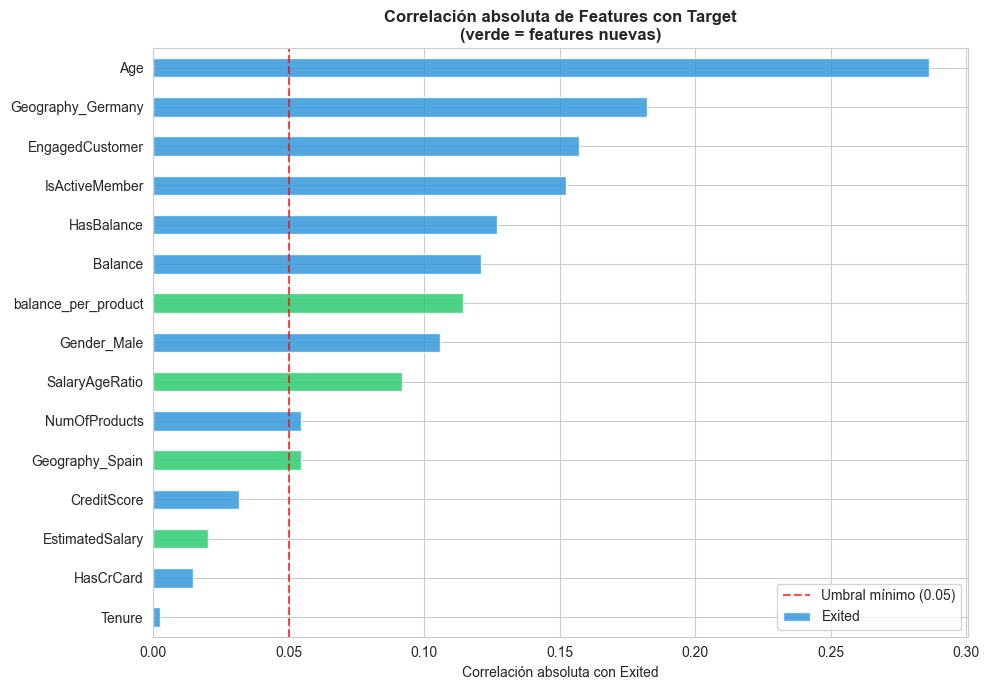


 Verificación features nuevas:
   balance_per_product      : 0.1141   Aporta valor
   HasBalance               : 0.1266   Aporta valor
   EngagedCustomer          : 0.1569   Aporta valor
   SalaryAgeRatio           : 0.0918   Aporta valor


In [16]:
# Verificamos que todas las features, incluidas las nuevas, aportan valor
temp_final = X_train_scaled.copy()
temp_final['Exited'] = y_train.values
corr_target = temp_final.corr(numeric_only=True)['Exited'].drop('Exited').abs().sort_values(ascending=False)

plt.figure(figsize=(10,7))
colores = ['#2ecc71' if c in nuevas else '#3498db' for c in corr_target.index]
corr_target.sort_values().plot(kind='barh', color=colores, alpha=0.85, edgecolor='white')
plt.axvline(0.05, color='red', linestyle='--', alpha=0.7, label='Umbral mínimo (0.05)')
plt.title('Correlación absoluta de Features con Target\n(verde = features nuevas)', fontweight='bold')
plt.xlabel('Correlación absoluta con Exited')
plt.legend()
plt.tight_layout()
plt.show()

print('\n Verificación features nuevas:')
for f in nuevas:
    if f in corr_target.index:
        val = corr_target[f]
        nivel = ' Aporta valor' if val > 0.05 else ' Correlación débil'
        print(f'   {f:25s}: {val:.4f}  {nivel}')

## 9. Resumen del Preprocesado

| Paso | Acción | Justificación |
|---|---|---|
| **Split primero** | 80/20 con stratify | Evita data leakage   |
| Duplicados | Sin duplicados | Dataset limpio |
| Missings | Mediana/Moda (preventivo) | Sin nulos, imputador listo para producción |
| Outliers | Capping P1-P99 | Conserva registros, bounds de train |
| `balance_per_product` | Balance / NumProductos | Concentración de dinero por producto |
| `HasBalance` | Saldo > 0 (binaria) | 36% clientes sin saldo — señal de desenganche |
| `EngagedCustomer` | Activo + >1 producto | Perfil más comprometido con el banco |
| `SalaryAgeRatio` | Salario / Edad | Riqueza relativa según etapa de vida |
| OHE | Geography, Gender | Sin orden implícito entre categorías |
| StandardScaler | Todas las numéricas | Fit solo en train — necesario para LR y KNN |